# Mạng Nơ-ron Hồi quy (RNN)

## 1. Giới thiệu về RNN

RNN là một loại mạng nơ-ron nhân tạo được thiết kế để xử lý *dữ liệu tuần tự* (sequential data), như chuỗi thời gian, văn bản, hoặc âm thanh. Điểm đặc biệt của RNN là khả năng "ghi nhớ" thông tin từ các bước trước đó nhờ cấu trúc vòng lặp.

### Tại sao cần RNN?

- Trong mạng nơ-ron truyền thống, mỗi đầu vào là độc lập, không có mối quan hệ với các đầu vào trước đó.
- Với RNN, thông tin từ bước trước được truyền sang bước hiện tại, cho phép học các mẫu trong chuỗi dữ liệu.

### Ứng dụng của RNN

- Dự đoán chuỗi thời gian (ví dụ: giá cổ phiếu).
- Xử lý ngôn ngữ tự nhiên (NLP): dịch máy, sinh văn bản.
- Nhận diện giọng nói.

## 2. Cấu trúc của RNN

RNN có một vòng lặp trong kiến trúc, cho phép trạng thái ẩn (hidden state) được cập nhật qua từng bước thời gian. Các thành phần cơ bản:

- **Đầu vào:** $x_t$ tại thời điểm $t$.
- **Trạng thái ẩn:** $h_t$, lưu trữ thông tin từ các bước trước.
- **Đầu ra:** $y_t$ tại thời điểm $t$.

### Sơ đồ cơ bản

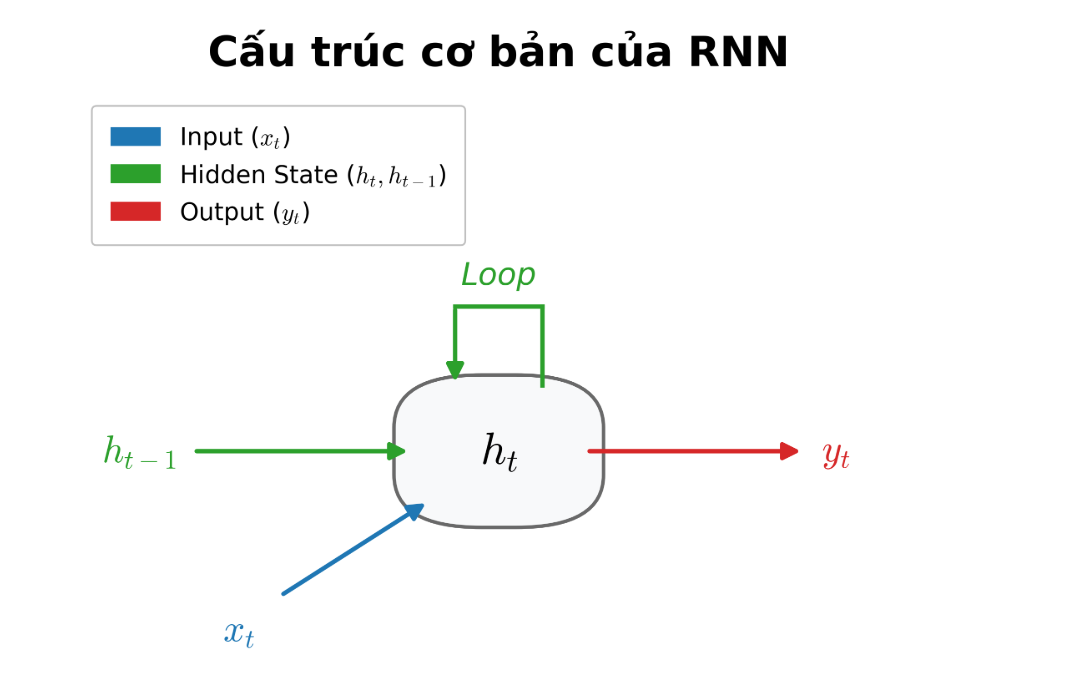


## 3. Công thức toán học của RNN

Trong RNN, tại mỗi thời điểm $t$, mô hình nhận đầu vào $x_t$, kết hợp với trạng thái ẩn từ bước trước $h_{t-1}$, rồi tạo ra trạng thái ẩn mới $h_t$. Từ trạng thái ẩn này, mô hình tiếp tục tính đầu ra $y_t$.

### 3.1. Công thức tính trạng thái ẩn

Trạng thái ẩn tại thời điểm $t$ được tính theo công thức:

$$
h_t = f(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$

Trong đó:
- $x_t$: vector đầu vào tại thời điểm $t$
- $h_{t-1}$: trạng thái ẩn tại thời điểm trước đó
- $W_{xh}$: ma trận trọng số từ đầu vào đến trạng thái ẩn
- $W_{hh}$: ma trận trọng số hồi quy giữa trạng thái ẩn trước và trạng thái ẩn hiện tại
- $b_h$: vector bias của tầng ẩn
- $f$: hàm kích hoạt phi tuyến, thường là $\tanh$ hoặc sigmoid

Công thức trên cho thấy trạng thái ẩn mới được hình thành từ hai nguồn thông tin:
- thông tin hiện tại từ đầu vào $x_t$
- thông tin quá khứ được lưu trong trạng thái ẩn $h_{t-1}$

Nhờ cơ chế này, RNN có thể mô hình hóa dữ liệu tuần tự và duy trì ngữ cảnh theo thời gian.

#### Ví dụ minh họa

Giả sử:

$$
x_t = [0.5,\ 0.1]^T
$$

$$
h_{t-1} = [0.2,\ 0.3]^T
$$

và các tham số:

$$
W_{xh} =
\begin{bmatrix}
0.1 & 0.2 \\
0.3 & 0.4
\end{bmatrix}
$$

$$
W_{hh} =
\begin{bmatrix}
0.5 & 0.6 \\
0.7 & 0.8
\end{bmatrix}
$$

$$
b_h = [0.1,\ 0.2]^T
$$

Giả sử hàm kích hoạt là:

$$
f = \tanh
$$

Ta tính lần lượt:

**Bước 1: Thành phần từ đầu vào**

$$
W_{xh}x_t =
\begin{bmatrix}
0.1 & 0.2 \\
0.3 & 0.4
\end{bmatrix}
\begin{bmatrix}
0.5 \\
0.1
\end{bmatrix}
=
\begin{bmatrix}
0.1 \times 0.5 + 0.2 \times 0.1 \\
0.3 \times 0.5 + 0.4 \times 0.1
\end{bmatrix}
=
\begin{bmatrix}
0.07 \\
0.19
\end{bmatrix}
$$

**Bước 2: Thành phần từ trạng thái trước**

$$
W_{hh}h_{t-1} =
\begin{bmatrix}
0.5 & 0.6 \\
0.7 & 0.8
\end{bmatrix}
\begin{bmatrix}
0.2 \\
0.3
\end{bmatrix}
=
\begin{bmatrix}
0.5 \times 0.2 + 0.6 \times 0.3 \\
0.7 \times 0.2 + 0.8 \times 0.3
\end{bmatrix}
=
\begin{bmatrix}
0.28 \\
0.38
\end{bmatrix}
$$

**Bước 3: Cộng với bias**

$$
W_{xh}x_t + W_{hh}h_{t-1} + b_h
=
\begin{bmatrix}
0.07 \\
0.19
\end{bmatrix}
+
\begin{bmatrix}
0.28 \\
0.38
\end{bmatrix}
+
\begin{bmatrix}
0.1 \\
0.2
\end{bmatrix}
=
\begin{bmatrix}
0.45 \\
0.77
\end{bmatrix}
$$

**Bước 4: Áp dụng hàm $\tanh$**

$$
h_t = \tanh([0.45,\ 0.77]^T) \approx [0.422,\ 0.646]^T
$$

Vậy trạng thái ẩn tại thời điểm $t$ là:

$$
h_t \approx [0.422,\ 0.646]^T
$$

### 3.2. Công thức tính đầu ra

Sau khi có trạng thái ẩn $h_t$, đầu ra tại thời điểm $t$ được tính theo công thức:

$$
y_t = g(W_{hy}h_t + b_y)
$$

Trong đó:
- $W_{hy}$: ma trận trọng số từ trạng thái ẩn đến đầu ra
- $b_y$: bias của tầng đầu ra
- $g$: hàm kích hoạt đầu ra

Tùy bài toán, hàm $g$ có thể khác nhau:
- dùng sigmoid cho phân loại nhị phân
- dùng softmax cho phân loại nhiều lớp
- hoặc không dùng hàm kích hoạt nếu là bài toán hồi quy

#### Ví dụ tiếp nối

Giả sử:

$$
h_t = [0.422,\ 0.646]^T
$$

$$
W_{hy} = [0.9,\ 0.8]
$$

$$
b_y = 0.05
$$

và hàm kích hoạt đầu ra là sigmoid:

$$
g = \sigma
$$

Ta tính:

**Bước 1: Nhân trọng số với trạng thái ẩn**

$$
W_{hy}h_t = [0.9,\ 0.8]
\begin{bmatrix}
0.422 \\
0.646
\end{bmatrix}
= 0.9 \times 0.422 + 0.8 \times 0.646
= 0.3798 + 0.5168
= 0.8966
$$

**Bước 2: Cộng bias**

$$
0.8966 + 0.05 = 0.9466
$$

**Bước 3: Áp dụng hàm sigmoid**

$$
y_t = \sigma(0.9466) = \frac{1}{1 + e^{-0.9466}} \approx 0.720
$$

Vậy đầu ra của mô hình tại thời điểm $t$ là:

$$
y_t \approx 0.72
$$

### 3.3. Ý nghĩa của quá trình tính toán

Từ hai công thức trên, có thể thấy rằng RNN hoạt động theo cơ chế lặp qua từng bước thời gian:
1. nhận đầu vào mới $x_t$
2. kết hợp với thông tin đã lưu trong $h_{t-1}$
3. tạo ra trạng thái mới $h_t$
4. sinh đầu ra $y_t$

Nhờ đó, mô hình không chỉ dựa vào dữ liệu hiện tại mà còn tận dụng được ngữ cảnh từ các bước trước trong chuỗi. Đây là đặc điểm cốt lõi giúp RNN phù hợp với các bài toán xử lý dữ liệu tuần tự như văn bản, âm thanh và chuỗi thời gian.

## 4. Huấn luyện RNN (Backpropagation Through Time - BPTT)

RNN được huấn luyện bằng thuật toán **lan truyền ngược qua thời gian** (*Backpropagation Through Time - BPTT*).  
Ý tưởng chính là "mở" mạng RNN theo từng bước thời gian, sau đó áp dụng lan truyền ngược tương tự như trong mạng nơ-ron truyền thống, nhưng trên toàn bộ chuỗi.

Giả sử chuỗi có độ dài $T$, tổng hàm mất mát được tính như sau:

$$
L = \sum_{t=1}^{T} L_t
$$

Trong đó:
- $L_t$ là mất mát tại thời điểm $t$
- $T$ là số bước thời gian của chuỗi

Do trạng thái ẩn tại thời điểm hiện tại phụ thuộc vào các trạng thái trước đó, nên khi tính gradient, sai số không chỉ ảnh hưởng đến một thời điểm riêng lẻ mà còn lan truyền ngược qua nhiều bước thời gian trước đó. Vì vậy, quá trình huấn luyện RNN phức tạp hơn so với mạng nơ-ron truyền thẳng thông thường.

Về mặt trực quan, gradient đối với ma trận trọng số hồi quy $W_{hh}$ có thể được biểu diễn như sau:

$$
\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial W_{hh}}
$$

Điều này cho thấy trọng số $W_{hh}$ được chia sẻ qua tất cả các bước thời gian, nên gradient cuối cùng là tổng đóng góp từ toàn bộ chuỗi.

### Vấn đề gradient biến mất và gradient bùng nổ

Trong thực tế, RNN thường gặp hai vấn đề quan trọng khi huấn luyện trên chuỗi dài:

- **Gradient biến mất (vanishing gradient):** gradient trở nên rất nhỏ sau nhiều lần lan truyền ngược, làm mô hình khó học được các phụ thuộc dài hạn
- **Gradient bùng nổ (exploding gradient):** gradient tăng quá lớn, gây mất ổn định trong quá trình cập nhật trọng số

Đặc biệt, hiện tượng **gradient biến mất** là một trong những hạn chế lớn nhất của RNN cơ bản. Khi chuỗi đầu vào quá dài, thông tin từ các bước đầu chuỗi thường bị suy giảm đáng kể trước khi đến được các bước sau, khiến mô hình khó ghi nhớ ngữ cảnh xa.

Vì lý do đó, các kiến trúc như **LSTM** và **GRU** đã được đề xuất để cải thiện khả năng ghi nhớ thông tin dài hạn và giảm ảnh hưởng của hiện tượng gradient biến mất.

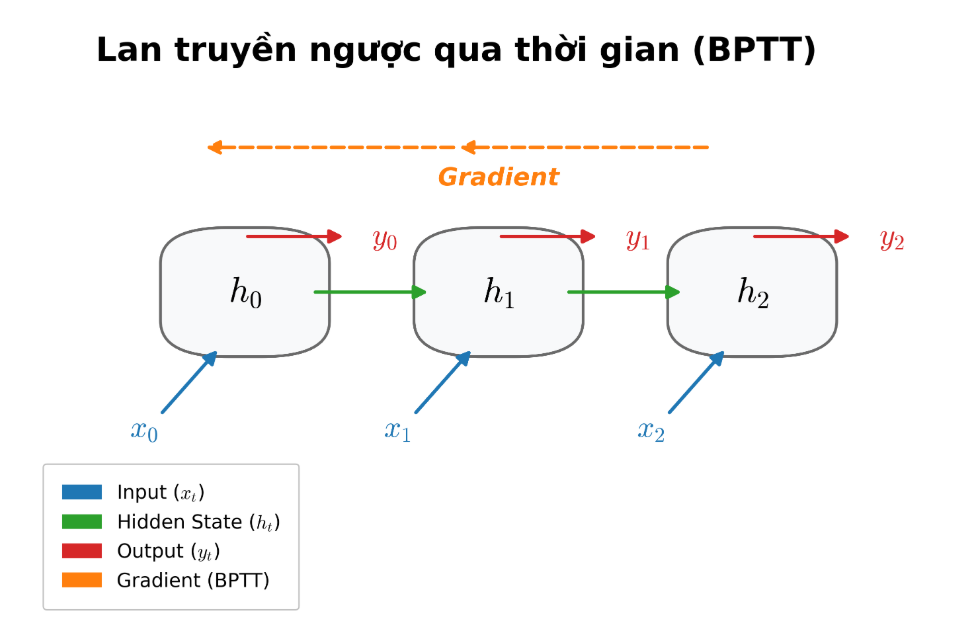

## 5. Ví dụ

Để dễ hình dung cách hoạt động của RNN, ta xét một ví dụ đơn giản trong bài toán dự đoán từ tiếp theo.

Giả sử chuỗi đầu vào là:

**"Tôi" $\rightarrow$ "thích"**

Mục tiêu của mô hình là dự đoán từ tiếp theo sau chuỗi này.  
Giả sử từ điển chỉ gồm ba từ:

- Tôi: $[1,0,0]$
- thích: $[0,1,0]$
- học: $[0,0,1]$

Tại bước thời gian thứ nhất, mô hình nhận từ **"Tôi"** dưới dạng vector one-hot $[1,0,0]$.  
Tại bước thời gian thứ hai, mô hình nhận từ **"thích"** dưới dạng vector $[0,1,0]$.  
Sau khi cập nhật trạng thái ẩn qua hai bước thời gian, RNN tạo ra đầu ra tại bước thứ hai để dự đoán từ tiếp theo.

Giả sử đầu ra của mô hình tại thời điểm đó là:

$$
y_2 = [0.1, 0.2, 0.7]
$$

Vector này có thể được hiểu là xác suất dự đoán cho ba từ trong từ điển.  
Trong đó:
- xác suất từ **"Tôi"** là $0.1$
- xác suất từ **"thích"** là $0.2$
- xác suất từ **"học"** là $0.7$

Vì giá trị lớn nhất nằm ở vị trí của từ **"học"**, nên mô hình dự đoán từ tiếp theo là:

$$
\text{"học"}
$$

Ví dụ này cho thấy RNN không xử lý từng từ một cách độc lập, mà sử dụng thông tin từ các bước trước đó để đưa ra dự đoán ở bước hiện tại. Đây chính là điểm khác biệt quan trọng giữa RNN và mạng nơ-ron truyền thẳng thông thường.

## 6. So sánh RNN và Feedforward Neural Network

| **RNN**                | **Feedforward NN**     |
|------------------------|------------------------|
| Xử lý dữ liệu tuần tự  | Đầu vào độc lập        |
| Có trạng thái ẩn $h_t$ | Không có bộ nhớ        |

## 7. Gradient biến mất

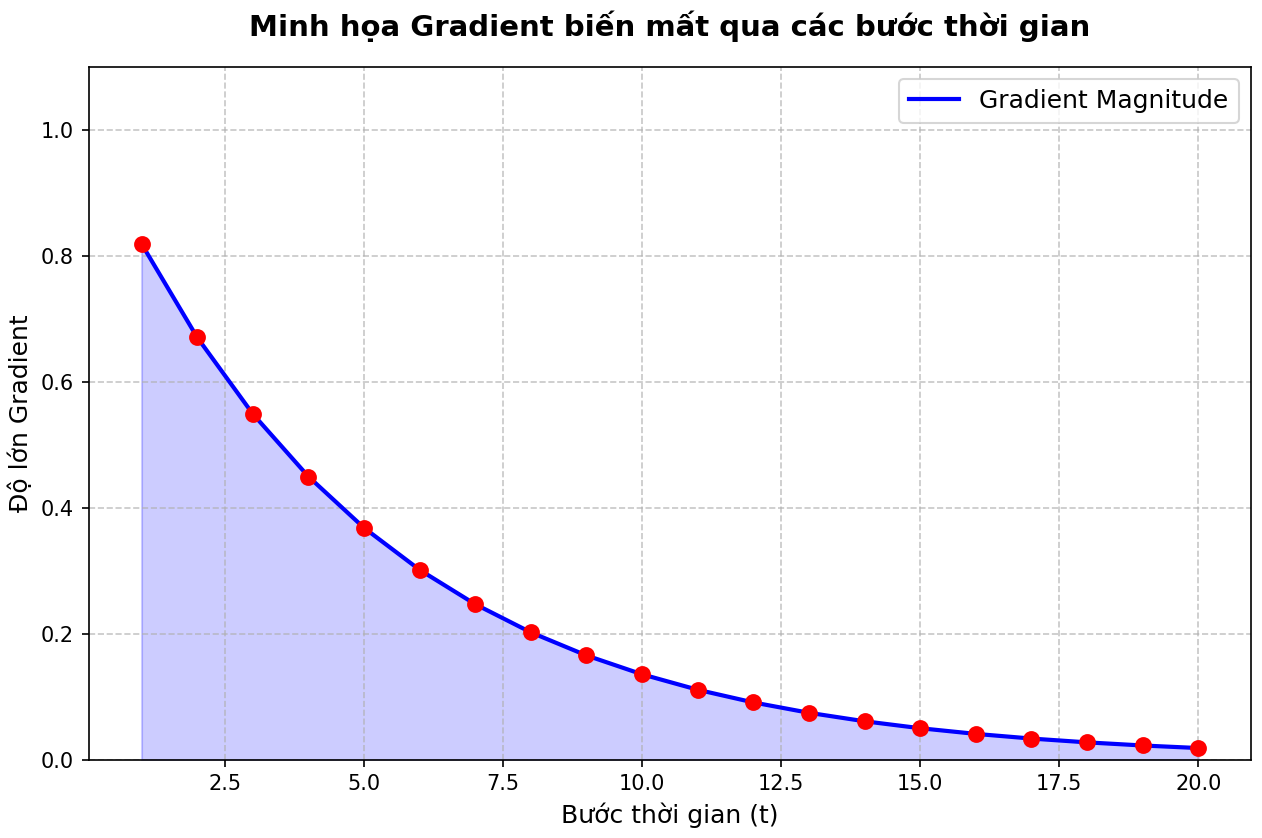


# BÀI THỰC HÀNH CƠ BẢN VỚI RNN

In [2]:
# Import các thư viện cần thiết
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [3]:
# 1. Chuẩn bị dữ liệu
# dữ liệu sin wave 
time_steps = 100
x = np.linspace(0, 20, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hóa dữ liệu về khoảng [0, 1]
data = (data - data.min()) / (data.max() - data.min())

# Chuyển thành tensor PyTorch và thêm chiều batch
data = torch.FloatTensor(data).unsqueeze(1)  # Shape: [100, 1]

# Hàm tạo chuỗi con cho huấn luyện
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length = 10  # Độ dài mỗi chuỗi
X, y = create_sequences(data, seq_length)  # X: [90, 10, 1], y: [90, 1]

In [4]:

# Chia 80% tập huấn luyện và 20% kiểm tra
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [5]:
# 2. Xây dựng mô hình RNN
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out[:, -1, :])  # Lấy đầu ra của bước cuối cùng
        return out, hidden
    
    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_size)

In [7]:
# Khởi tạo mô hình
model = RNN(input_size=1, hidden_size=20, output_size=1)

In [8]:
# 3. Định nghĩa hàm mất mát và tối ưu hóa
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [9]:
# 4. Huấn luyện mô hình
num_epochs = 100
batch_size = 16
loss_history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    hidden = model.init_hidden(batch_size)
    
    # Tạo các batch ngẫu nhiên
    indices = torch.randperm(len(X_train))[:batch_size]
    X_batch = X_train[indices]
    y_batch = y_train[indices]
    
    hidden = model.init_hidden(batch_size)
    
    output, hidden = model(X_batch, hidden)
    loss = criterion(output, y_batch)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    total_loss += loss.item()
    loss_history.append(total_loss)  # Lưu loss
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}')

Epoch [10/100], Loss: 0.0546
Epoch [20/100], Loss: 0.0159
Epoch [30/100], Loss: 0.0066
Epoch [40/100], Loss: 0.0031
Epoch [50/100], Loss: 0.0024
Epoch [60/100], Loss: 0.0026
Epoch [70/100], Loss: 0.0032
Epoch [80/100], Loss: 0.0031
Epoch [90/100], Loss: 0.0019
Epoch [100/100], Loss: 0.0037


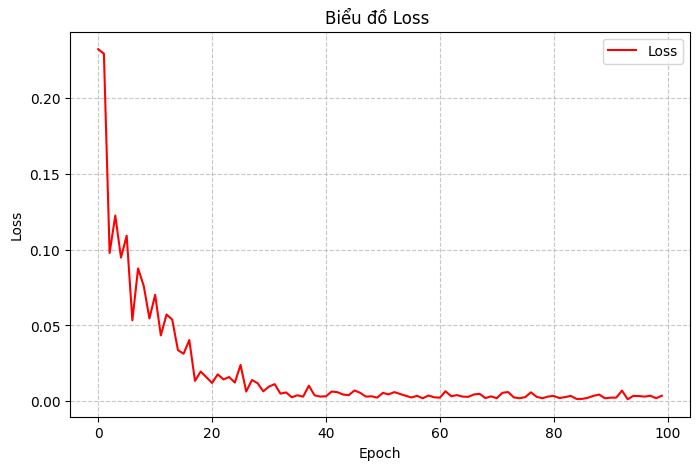

In [10]:
# Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Loss", color='red')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Biểu đồ Loss ")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [11]:
# 5. Đánh giá mô hình
model.eval()
with torch.no_grad():
    hidden = model.init_hidden(1)
    predictions = []
    inputs = X_test[0].unsqueeze(0)  # Bắt đầu với mẫu đầu tiên
    
    for _ in range(len(X_test)):
        output, hidden = model(inputs, hidden)
        predictions.append(output.item())
        inputs = torch.cat((inputs[:, 1:, :], output.unsqueeze(0)), dim=1)



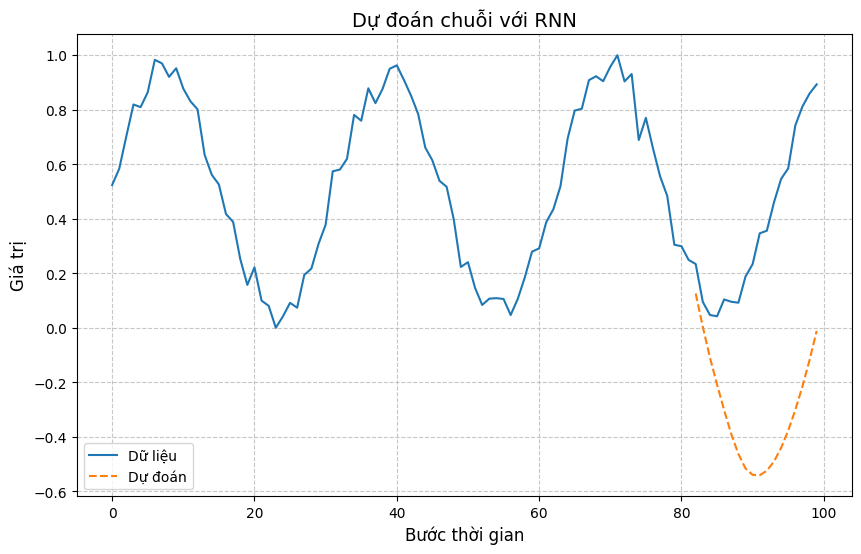

In [12]:
# Vẽ biểu đồ dự đoán
plt.figure(figsize=(10, 6))
plt.plot(data.numpy(), label='Dữ liệu')
plt.plot(np.arange(len(data) - len(y_test), len(data)), predictions, label='Dự đoán', linestyle='--')
plt.title('Dự đoán chuỗi với RNN', fontsize=14)
plt.xlabel('Bước thời gian', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
# 6. Một số dự đoán để kiểm tra
print("\nDự đoán trên tập kiểm tra:")
for i in range(5):
    print(f'Dự đoán {i}: {predictions[i]:.4f}, Thực tế: {y_test[i].item():.4f}')



Dự đoán trên tập kiểm tra:
Dự đoán 0: 0.1259, Thực tế: 0.2340
Dự đoán 1: 0.0037, Thực tế: 0.0951
Dự đoán 2: -0.1092, Thực tế: 0.0470
Dự đoán 3: -0.2080, Thực tế: 0.0422
Dự đoán 4: -0.3025, Thực tế: 0.1040


# BÀI TẬP VỀ NHÀ

# Dự báo chuỗi thời gian bằng RNN

## Mô tả bài toán

Trong buổi học trên lớp, chúng ta đã làm quen với bài toán dự báo chuỗi thời gian bằng mô hình RNN trên dữ liệu sóng sin đơn giản.  
Để hiểu sâu hơn về cách hoạt động của mô hình và rèn luyện kỹ năng xử lý dữ liệu chuỗi, ở bài tập này em sẽ xây dựng một mô hình dự báo trên **dữ liệu đa biến**, phức tạp hơn so với ví dụ trên lớp.

Mục tiêu của bài là sử dụng các giá trị trong quá khứ của nhiều đặc trưng để dự đoán giá trị của biến mục tiêu ở thời điểm tiếp theo.

## Mục tiêu cần đạt

Sau khi hoàn thành bài tập, em cần:

- Biết cách tạo và xử lý dữ liệu chuỗi thời gian.
- Biết cách chuẩn hóa dữ liệu trước khi đưa vào mô hình.
- Biết cách tạo các chuỗi con phục vụ huấn luyện.
- Xây dựng được mô hình RNN bằng PyTorch.
- Thực hiện huấn luyện, đánh giá và trực quan hóa kết quả.

## Dữ liệu sử dụng

Khác với ví dụ trên lớp chỉ có một chuỗi sin, trong bài này dữ liệu gồm nhiều đặc trưng hơn:

- `feature_1`: chuỗi dạng sin
- `feature_2`: chuỗi dạng cos
- `feature_3`: chuỗi có xu hướng tăng nhẹ kèm nhiễu
- `target`: biến mục tiêu được tạo từ tổ hợp của các đặc trưng trên

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


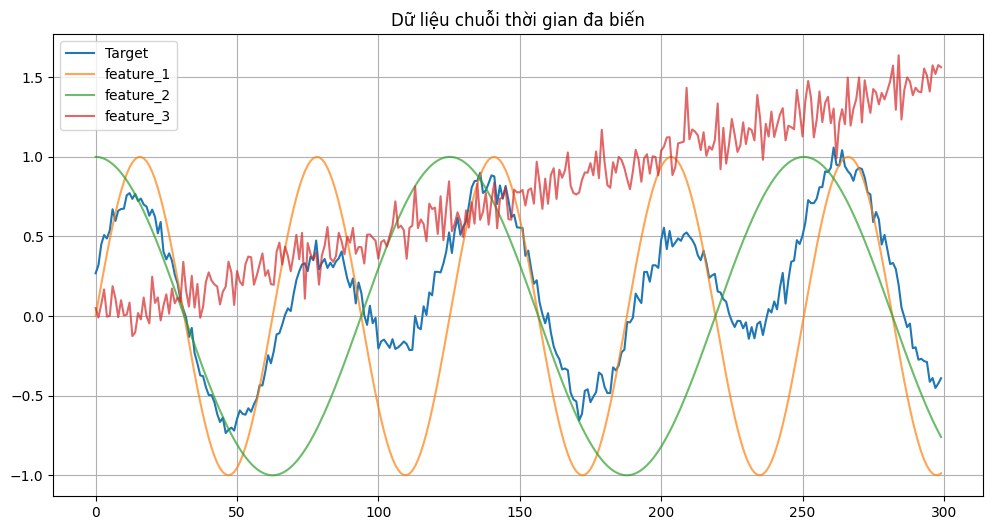

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)

feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)

target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target
})

print(df.head())

plt.figure(figsize=(12,6))
plt.plot(df['target'], label='Target')
plt.plot(df['feature_1'], label='feature_1', alpha=0.7)
plt.plot(df['feature_2'], label='feature_2', alpha=0.7)
plt.plot(df['feature_3'], label='feature_3', alpha=0.7)
plt.legend()
plt.title("Dữ liệu chuỗi thời gian đa biến")
plt.grid(True)
plt.show()

## Yêu cầu bài tập

### Phần 1. Tiền xử lý dữ liệu

Thực hiện các yêu cầu sau:

- Chuẩn hóa dữ liệu về khoảng `[0, 1]` hoặc dùng chuẩn hóa z-score.
- Tạo các chuỗi con với độ dài `seq_length = 20`.
- Chia dữ liệu theo tỉ lệ:
  - 70% cho tập huấn luyện
  - 15% cho tập validation
  - 15% cho tập kiểm tra

### Phần 2. Xây dựng mô hình RNN

Xây dựng mô hình RNN bằng PyTorch với cấu hình gợi ý như sau:

- `input_size = 3`
- `hidden_size = 32`
- `output_size = 1`

Yêu cầu trong quá trình huấn luyện:

- Sử dụng hàm mất mát `MSELoss`.
- Sử dụng bộ tối ưu `Adam`.
- Huấn luyện mô hình trong `150 epochs`.
- Lưu lại các giá trị sau:
  - `train loss`
  - `validation loss`

### Phần 3. Đánh giá mô hình

Sau khi huấn luyện xong, thực hiện các yêu cầu sau:

- Dự đoán trên tập test.
- Tính các chỉ số đánh giá:
  - `MSE`
  - `MAE`
- Vẽ biểu đồ so sánh:
  - giá trị thực
  - giá trị dự đoán

  ### Phần 4. Yêu cầu nâng cao

- Thử ít nhất **2 giá trị khác nhau của `seq_length`** (ví dụ: 10, 20, 30) và nhận xét xem độ dài chuỗi ảnh hưởng như thế nào đến kết quả dự đoán.
- Thay đổi số lượng **hidden_size** (ví dụ: 16, 32, 64) để so sánh hiệu quả của mô hình.
- Tăng số epoch huấn luyện và quan sát sự thay đổi của `train loss` và `validation loss`.
- Thử dự đoán **nhiều bước tiếp theo** (ví dụ: 3 bước hoặc 5 bước) thay vì chỉ dự đoán 1 bước.
- Sử dụng **dropout** hoặc tăng số tầng của mô hình RNN để kiểm tra xem mô hình có cải thiện hay không.
- Thay đổi **learning rate** của bộ tối ưu Adam và so sánh kết quả.
- Vẽ thêm biểu đồ thể hiện sai số dự đoán theo từng thời điểm trên tập test.
- Viết phần nhận xét ngắn về những yếu tố làm mô hình dự đoán tốt hơn hoặc kém hơn.

Deadline: 28/03/2026


In [15]:
# PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU

# Chuẩn hóa dữ liệu về khoảng [0, 1] 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values)  # shape: (300, 4)

# Tách features và target sau khi chuẩn hóa
features_scaled = data_scaled[:, :3]   # 3 features đầu
target_scaled   = data_scaled[:, 3:]   # target (cột cuối)

# Tạo chuỗi con
seq_length = 20

def create_sequences_multivariate(features, target, seq_len):
    X, y = [], []
    for i in range(len(features) - seq_len):
        X.append(features[i : i + seq_len])          # (seq_len, 3)
        y.append(target[i + seq_len])                 # (1,)
    X = torch.FloatTensor(np.array(X))   # (N, seq_len, 3)
    y = torch.FloatTensor(np.array(y))   # (N, 1)
    return X, y

X_all, y_all = create_sequences_multivariate(features_scaled, target_scaled, seq_length)
print(f"X shape: {X_all.shape}, y shape: {y_all.shape}")

# Chia train/val/test theo tỉ lệ 70/15/15 
n = len(X_all)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

X_train, y_train = X_all[:train_end],       y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],          y_all[val_end:]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

X shape: torch.Size([280, 20, 3]), y shape: torch.Size([280, 1])
Train: 196, Val: 42, Test: 42


Epoch [30/150] | Train Loss: 0.0009 | Val Loss: 0.0014
Epoch [60/150] | Train Loss: 0.0011 | Val Loss: 0.0009
Epoch [90/150] | Train Loss: 0.0008 | Val Loss: 0.0007
Epoch [120/150] | Train Loss: 0.0011 | Val Loss: 0.0009
Epoch [150/150] | Train Loss: 0.0010 | Val Loss: 0.0009


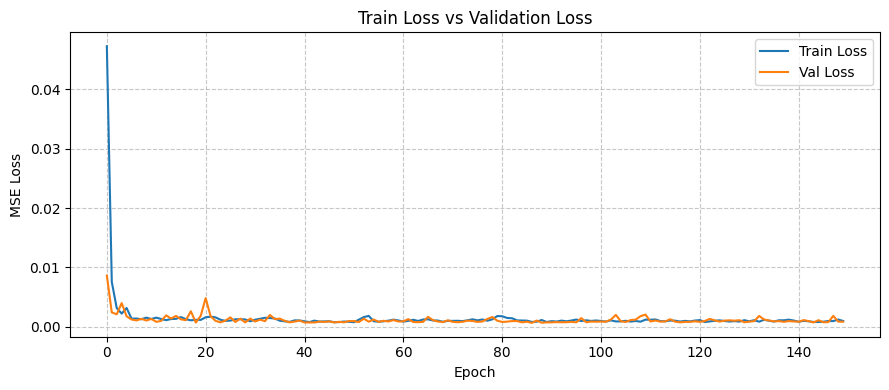

In [16]:
# PHẦN 2: XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH 

# Định nghĩa mô hình 
class RNNModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1, num_layers=1, dropout=0.0):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.rnn = nn.RNN(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])   # lấy bước cuối cùng
        return out

# Khởi tạo 
model     = RNNModel(input_size=3, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Huấn luyện
num_epochs  = 150
batch_size  = 32
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    # Mini-batch ngẫu nhiên
    perm = torch.randperm(len(X_train))
    epoch_loss = 0.0
    n_batches  = 0

    for start in range(0, len(X_train), batch_size):
        idx     = perm[start : start + batch_size]
        xb, yb  = X_train[idx], y_train[idx]

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Vẽ biểu đồ Train vs Val Loss
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Train Loss vs Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Test MSE : 0.002937
Test MAE : 0.045566


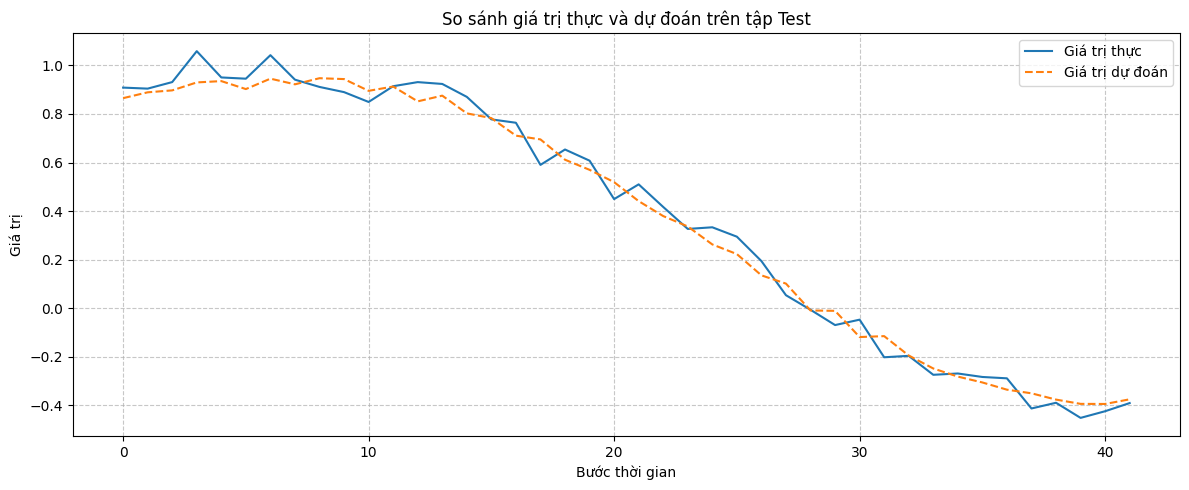

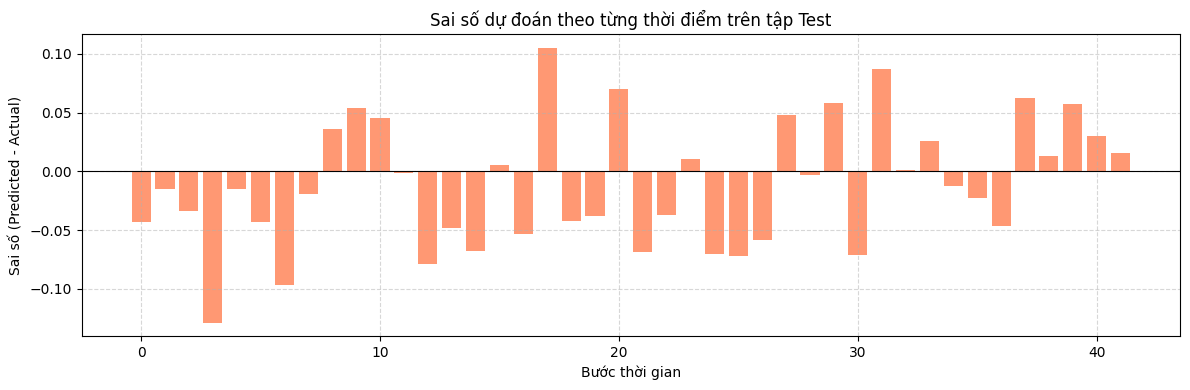

In [17]:
# PHẦN 3: ĐÁNH GIÁ MÔ HÌNH 

model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test).numpy()   # (N_test, 1)

# Chuyển ngược về thang gốc
# scaler xử lý toàn bộ 4 cột; cần inverse chỉ cột target (index 3)
def inverse_target(scaled_vals):
    """scaled_vals: (N,1) -> original scale"""
    dummy = np.zeros((len(scaled_vals), 4))
    dummy[:, 3] = scaled_vals[:, 0]
    return scaler.inverse_transform(dummy)[:, 3]

y_pred_orig = inverse_target(y_pred_scaled)
y_true_orig = inverse_target(y_test.numpy())

# Tính MSE và MAE 
mse = np.mean((y_pred_orig - y_true_orig) ** 2)
mae = np.mean(np.abs(y_pred_orig - y_true_orig))
print(f"Test MSE : {mse:.6f}")
print(f"Test MAE : {mae:.6f}")

# Biểu đồ so sánh thực tế vs dự đoán
plt.figure(figsize=(12, 5))
plt.plot(y_true_orig, label="Giá trị thực", linewidth=1.5)
plt.plot(y_pred_orig, label="Giá trị dự đoán", linestyle="--", linewidth=1.5)
plt.xlabel("Bước thời gian")
plt.ylabel("Giá trị")
plt.title("So sánh giá trị thực và dự đoán trên tập Test")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Biểu đồ sai số theo từng thời điểm 
errors = y_pred_orig - y_true_orig
plt.figure(figsize=(12, 4))
plt.bar(range(len(errors)), errors, color="coral", alpha=0.8)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Bước thời gian")
plt.ylabel("Sai số (Predicted - Actual)")
plt.title("Sai số dự đoán theo từng thời điểm trên tập Test")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Thực nghiệm 1: So sánh seq_length (hidden=32, epochs=150, lr=0.01)
  seq=10                                   | MSE=0.003796 | MAE=0.051544
  seq=20                                   | MSE=0.004123 | MAE=0.054575
  seq=30                                   | MSE=0.006370 | MAE=0.066617


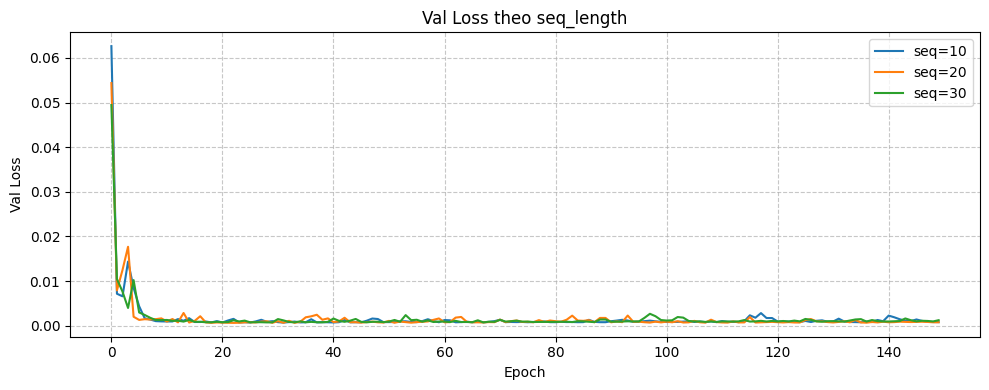

Thực nghiệm 2: So sánh hidden_size (seq=20, epochs=150, lr=0.01)
  hidden=16                                | MSE=0.002711 | MAE=0.041817
  hidden=32                                | MSE=0.005021 | MAE=0.056223
  hidden=64                                | MSE=0.003197 | MAE=0.046212


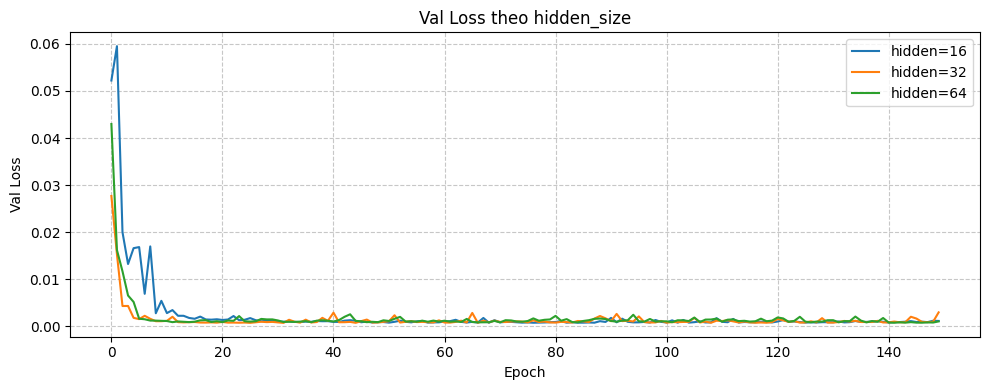

Thực nghiệm 3: So sánh số epoch (seq=20, hidden=32, lr=0.01)
  epochs=50                                | MSE=0.002630 | MAE=0.042650
  epochs=150                               | MSE=0.002882 | MAE=0.043215
  epochs=300                               | MSE=0.003856 | MAE=0.051329
Thực nghiệm 4: Dự đoán nhiều bước (multi-step = 3)
Dự đoán 3 bước tiếp theo:
  Bước 1: Dự đoán=0.8651, Thực tế=0.9085
  Bước 2: Dự đoán=0.9312, Thực tế=0.9043
  Bước 3: Dự đoán=0.9649, Thực tế=0.9312
Thực nghiệm 5: Mô hình 2 tầng RNN + Dropout (seq=20, hidden=32)
  Deep RNN (2 tầng, dropout=0.3) | MSE=0.012654 | MAE=0.094060
Thực nghiệm 6: So sánh learning rate (seq=20, hidden=32, epochs=150)
  lr=0.001                                 | MSE=0.003336 | MAE=0.047673
  lr=0.01                                  | MSE=0.002923 | MAE=0.044486
  lr=0.05                                  | MSE=0.004849 | MAE=0.053290
NHẬN XÉT TỔNG HỢP

1. seq_length (độ dài chuỗi):
   - seq quá ngắn (10) → mô hình không nắm được đủ ngữ c

In [18]:
# PHẦN 4: YÊU CẦU NÂNG CAO 

# 4a. So sánh các seq_length khác nhau: 10, 20, 30
def run_experiment(seq_len, hidden_size=32, epochs=150, lr=0.01, label=""):
    """Huấn luyện và trả về test MSE, MAE, val_losses."""
    X_a, y_a = create_sequences_multivariate(features_scaled, target_scaled, seq_len)
    n        = len(X_a)
    te       = int(0.70 * n)
    ve       = int(0.85 * n)
    Xtr, ytr = X_a[:te],   y_a[:te]
    Xva, yva = X_a[te:ve], y_a[te:ve]
    Xts, yts = X_a[ve:],   y_a[ve:]

    m     = RNNModel(input_size=3, hidden_size=hidden_size, output_size=1)
    crit  = nn.MSELoss()
    opt   = torch.optim.Adam(m.parameters(), lr=lr)
    vl_list = []

    for ep in range(epochs):
        m.train()
        perm   = torch.randperm(len(Xtr))
        for start in range(0, len(Xtr), 32):
            idx    = perm[start:start+32]
            xb, yb = Xtr[idx], ytr[idx]
            opt.zero_grad()
            loss = crit(m(xb), yb)
            loss.backward()
            opt.step()
        m.eval()
        with torch.no_grad():
            vl_list.append(crit(m(Xva), yva).item())

    m.eval()
    with torch.no_grad():
        pred = m(Xts).numpy()
    po = inverse_target(pred)
    to = inverse_target(yts.numpy())
    mse_val = np.mean((po - to) ** 2)
    mae_val = np.mean(np.abs(po - to))
    print(f"  {label:40s} | MSE={mse_val:.6f} | MAE={mae_val:.6f}")
    return mse_val, mae_val, vl_list

print("Thực nghiệm 1: So sánh seq_length (hidden=32, epochs=150, lr=0.01)")
results_seq = {}
for sl in [10, 20, 30]:
    key = f"seq={sl}"
    m, a, vl = run_experiment(sl, hidden_size=32, label=key)
    results_seq[key] = (m, a, vl)

# Vẽ val loss các seq_length
plt.figure(figsize=(10, 4))
for key, (_, _, vl) in results_seq.items():
    plt.plot(vl, label=key)
plt.xlabel("Epoch"); plt.ylabel("Val Loss")
plt.title("Val Loss theo seq_length")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.7); plt.tight_layout(); plt.show()


# 4b. So sánh hidden_size: 16, 32, 64
print("Thực nghiệm 2: So sánh hidden_size (seq=20, epochs=150, lr=0.01)")

results_hidden = {}
for hs in [16, 32, 64]:
    key = f"hidden={hs}"
    m, a, vl = run_experiment(20, hidden_size=hs, label=key)
    results_hidden[key] = (m, a, vl)

plt.figure(figsize=(10, 4))
for key, (_, _, vl) in results_hidden.items():
    plt.plot(vl, label=key)
plt.xlabel("Epoch"); plt.ylabel("Val Loss")
plt.title("Val Loss theo hidden_size")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.7); plt.tight_layout(); plt.show()


# 4c. Tăng số epoch: 50, 150, 300
print("Thực nghiệm 3: So sánh số epoch (seq=20, hidden=32, lr=0.01)")

results_epoch = {}
for ep in [50, 150, 300]:
    key = f"epochs={ep}"
    m, a, vl = run_experiment(20, hidden_size=32, epochs=ep, label=key)
    results_epoch[key] = (m, a, vl)


# 4d. Dự đoán nhiều bước tiếp theo (multi-step: 3 bước)
print("Thực nghiệm 4: Dự đoán nhiều bước (multi-step = 3)")

# Dùng mô hình đã huấn luyện ở Phần 2, dự đoán 3 bước liên tiếp
def predict_multi_step(mdl, X_start, steps):
    """Dự đoán liên tiếp `steps` bước từ chuỗi đầu `X_start` (1, seq_len, 3)."""
    mdl.eval()
    preds = []
    current = X_start.clone()
    with torch.no_grad():
        for _ in range(steps):
            out = mdl(current)           # (1,1)
            preds.append(out.item())
            # Bước tiếp: bỏ timestep đầu, thêm dự đoán vào cuối
            # Giả sử dùng pred làm feature_1; feature_2,3 lấy từ timestep cuối
            last_feat = current[:, -1:, 1:]            # (1,1,2)
            new_step  = torch.cat(
                [out.unsqueeze(-1), last_feat], dim=-1  # (1,1,3)
            )
            current = torch.cat([current[:, 1:, :], new_step], dim=1)
    return preds

start_input = X_test[:1]   # chuỗi đầu tiên của tập test
ms_preds_scaled = predict_multi_step(model, start_input, steps=3)

# Inverse transform từng giá trị
ms_preds_orig = []
for val in ms_preds_scaled:
    arr = np.array([[val]])
    ms_preds_orig.append(inverse_target(arr)[0])

y_true_3 = inverse_target(y_test[:3].numpy())
print("Dự đoán 3 bước tiếp theo:")
for i, (p, t) in enumerate(zip(ms_preds_orig, y_true_3)):
    print(f"  Bước {i+1}: Dự đoán={p:.4f}, Thực tế={t:.4f}")


# 4e. Dropout + nhiều tầng
print("Thực nghiệm 5: Mô hình 2 tầng RNN + Dropout (seq=20, hidden=32)")

class RNNModelDeep(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.rnn = nn.RNN(input_size, hidden_size,
                          num_layers=num_layers, batch_first=True, dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0  = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)
        out = self.drop(out[:, -1, :])
        return self.fc(out)

def train_model(mdl, Xtr, ytr, Xva, yva, epochs=150, lr=0.01):
    crit  = nn.MSELoss()
    opt   = torch.optim.Adam(mdl.parameters(), lr=lr)
    vl_list = []
    for ep in range(epochs):
        mdl.train()
        perm = torch.randperm(len(Xtr))
        for start in range(0, len(Xtr), 32):
            idx = perm[start:start+32]
            opt.zero_grad()
            loss = crit(mdl(Xtr[idx]), ytr[idx])
            loss.backward(); opt.step()
        mdl.eval()
        with torch.no_grad():
            vl_list.append(crit(mdl(Xva), yva).item())
    return vl_list

# Dùng lại split từ Phần 1 (seq=20)
deep_model = RNNModelDeep()
vl_deep = train_model(deep_model, X_train, y_train, X_val, y_val, epochs=150)

deep_model.eval()
with torch.no_grad():
    dp = deep_model(X_test).numpy()
dp_orig = inverse_target(dp)
print(f"  Deep RNN (2 tầng, dropout=0.3) | MSE={np.mean((dp_orig-y_true_orig)**2):.6f} | MAE={np.mean(np.abs(dp_orig-y_true_orig)):.6f}")


# 4f. So sánh learning rate: 0.001, 0.01, 0.05
print("Thực nghiệm 6: So sánh learning rate (seq=20, hidden=32, epochs=150)")

for lr_ in [0.001, 0.01, 0.05]:
    key = f"lr={lr_}"
    run_experiment(20, hidden_size=32, epochs=150, lr=lr_, label=key)


# Nhận xét tổng hợp

print("NHẬN XÉT TỔNG HỢP")
print("""
1. seq_length (độ dài chuỗi):
   - seq quá ngắn (10) → mô hình không nắm được đủ ngữ cảnh, dự đoán kém.
   - seq quá dài (30) → thêm thông tin nhưng rủi ro gradient biến mất cao hơn;
     với dữ liệu này khoảng 20 là cân bằng tốt.

2. hidden_size (kích thước tầng ẩn):
   - hidden nhỏ (16) → mô hình underfit, độ chính xác thấp.
   - hidden lớn (64) → tốt hơn nhưng tốn tài nguyên tính toán và dễ overfit.
   - hidden=32 là lựa chọn cân bằng cho tập dữ liệu 300 điểm.

3. Số epoch:
   - Ít epoch (50) → underfitting, model chưa hội tụ.
   - Nhiều epoch (300) → train loss tiếp tục giảm nhưng val loss
     có thể tăng nhẹ → dấu hiệu overfitting.

4. Multi-step prediction:
   - Sai số tích lũy theo từng bước do dự đoán trước được dùng làm
     đầu vào bước sau; bước càng xa, sai số càng lớn.

5. Dropout + 2 tầng RNN:
   - Giúp giảm overfitting; val loss ổn định hơn khi số epoch lớn.
   - Tuy nhiên cần điều chỉnh dropout rate phù hợp.

6. Learning rate:
   - lr quá nhỏ (0.001) → hội tụ chậm, cần nhiều epoch hơn.
   - lr quá lớn (0.05) → dao động, không ổn định.
   - lr=0.01 phù hợp cho bài toán này.
""")